DSCI 552 Final Project
===================

- Name: Umaeshwer Shankar
- GitHub Username: umaeshwer
- USD ID: 7601-5514-88

## Imports

In [1]:
import os
import io
import logging
from pathlib import Path
from contextlib import redirect_stdout, redirect_stderr
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50, ResNet101, EfficientNetB0, VGG16, DenseNet201

# each model expects a different input normalization, so we alias them here
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet50
from tensorflow.keras.applications.resnet import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_efficientnet
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg16
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet

from sklearn.metrics import precision_score, recall_score, roc_auc_score, f1_score, classification_report, confusion_matrix

print("Available devices:", tf.config.list_physical_devices())
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU detected: {gpu_devices[0].name}")
else:
    print("No GPU detected. Training will run on CPU.")

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


2026-05-08 05:59:55.397568: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778219995.424822    4014 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778219995.433563    4014 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778219995.455738    4014 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778219995.455764    4014 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778219995.455767    4014 computation_placer.cc:177] computation placer alr

Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPU detected: /physical_device:GPU:0


## 1. Transfer Learning for Image Classification

This notebook uses Python with Keras for transfer learning.

Reference: `https://keras.io`

## (a)

In this problem, we are trying to build a classifier that distinguishes images of five types of fungi.

## (b) Data Exploration and Pre-processing

### i.

Randomly divide each class into 75% training, 15% validation, and 10% test sets. You can encode your classes using one-hot encoding.

In [2]:
data_dir = Path('/kaggle/input/datasets/umaeshwershankar/defungi/defungi')
class_paths = [data_dir / f'C{i}' for i in range(1, 6)]

print("Fungi Classes Data Overview:")
print("=" * 60)
for class_path in class_paths:
    if class_path.exists():
        image_count = len(list(class_path.glob('*.*')))
        print(f"{class_path.name}: {image_count} images")
    else:
        print(f"{class_path.name}: NOT FOUND")
print("=" * 60)


Fungi Classes Data Overview:
C1: 4404 images
C2: 2334 images
C3: 819 images
C4: 818 images
C5: 739 images


In [3]:
TARGET_SIZE = (224, 224)
SPLIT_RATIOS = {'train': 0.75, 'val': 0.15, 'test': 0.10}

LABEL_MAP = {f'C{i}': i - 1 for i in range(1, 6)}
NUM_CLASSES = len(LABEL_MAP)

rows = []
print("\nData Split Overview:")
print("=" * 60)

for class_path in class_paths:
    class_name = class_path.name
    images = sorted([
        p for p in class_path.glob('*')
        if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}
    ])
    random.shuffle(images)

    n = len(images)
    n_train = int(n * SPLIT_RATIOS['train'])
    n_val   = int(n * SPLIT_RATIOS['val'])
    n_test  = n - n_train - n_val

    splits = {
        'train': images[:n_train],
        'val'  : images[n_train : n_train + n_val],
        'test' : images[n_train + n_val:]
    }

    print(f"\n{class_name}: {n} total images")
    print(f"  Training: {n_train} ({SPLIT_RATIOS['train']*100:.0f}%)")
    print(f"  Validation: {n_val} ({SPLIT_RATIOS['val']*100:.0f}%)")
    print(f"  Test: {n_test} ({SPLIT_RATIOS['test']*100:.0f}%)")

    for subset_name, subset_images in splits.items():
        for img_path in subset_images:
            rows.append({
                'filepath' : str(img_path),
                'label'    : class_name,
                'subset'   : subset_name,
                'label_idx': LABEL_MAP[class_name]
            })

df = pd.DataFrame(rows)
train_df = df[df['subset'] == 'train'].reset_index(drop=True)
val_df   = df[df['subset'] == 'val'].reset_index(drop=True)
test_df  = df[df['subset'] == 'test'].reset_index(drop=True)

print("\n" + "=" * 60)
print("Distribution summary:")
print(df.groupby(['subset', 'label']).size().unstack(fill_value=0))
print("=" * 60)



Data Split Overview:

C1: 4404 total images
  Training: 3303 (75%)
  Validation: 660 (15%)
  Test: 441 (10%)

C2: 2334 total images
  Training: 1750 (75%)
  Validation: 350 (15%)
  Test: 234 (10%)

C3: 819 total images
  Training: 614 (75%)
  Validation: 122 (15%)
  Test: 83 (10%)

C4: 818 total images
  Training: 613 (75%)
  Validation: 122 (15%)
  Test: 83 (10%)

C5: 739 total images
  Training: 554 (75%)
  Validation: 110 (15%)
  Test: 75 (10%)

Distribution summary:
label     C1    C2   C3   C4   C5
subset                           
test     441   234   83   83   75
train   3303  1750  614  613  554
val      660   350  122  122  110


### ii.

In case all the images do not have the same size, zero-pad or resize the images in your dataset. This can be done using various tools, including OpenCV.

In [4]:
AUTOTUNE   = tf.data.AUTOTUNE
BATCH_SIZE = 5

PREPROCESS_FN = {
    'ResNet50'      : preprocess_resnet50,
    'ResNet101'     : preprocess_resnet,
    'EfficientNetB0': preprocess_efficientnet,
    'VGG16'         : preprocess_vgg16,
    'DenseNet201'   : preprocess_densenet,
}

# augmentation only applied during training
augmentation_pipeline = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.055),   # ~20 degrees
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.2, 0.2),
    layers.RandomContrast(0.2),
], name="augmentation")


def _load_and_pad(filepath, label):
    raw   = tf.io.read_file(filepath)
    image = tf.image.decode_image(raw, channels=3, expand_animations=False)
    image = tf.cast(image, tf.float32)
    image = tf.image.resize_with_pad(image, TARGET_SIZE[0], TARGET_SIZE[1])
    return image, label


def make_dataset(filepaths, labels_idx, preprocess_fn, augment=False, shuffle=False):
    labels_oh = tf.one_hot(labels_idx, NUM_CLASSES)
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels_oh))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(filepaths), seed=42, reshuffle_each_iteration=True)

    ds = ds.map(_load_and_pad, num_parallel_calls=AUTOTUNE)

    if augment:
        ds = ds.map(
            lambda img, lbl: (augmentation_pipeline(img, training=True), lbl),
            num_parallel_calls=AUTOTUNE
        )

    # normalize pixels for the specific backbone
    ds = ds.map(
        lambda img, lbl: (preprocess_fn(img), lbl),
        num_parallel_calls=AUTOTUNE
    )

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


def get_datasets(model_name):
    preprocess_fn = PREPROCESS_FN[model_name]
    train_ds = make_dataset(
        train_df['filepath'].tolist(), train_df['label_idx'].tolist(),
        preprocess_fn, augment=True, shuffle=True
    )
    val_ds = make_dataset(
        val_df['filepath'].tolist(), val_df['label_idx'].tolist(),
        preprocess_fn, augment=False, shuffle=False
    )
    test_ds = make_dataset(
        test_df['filepath'].tolist(), test_df['label_idx'].tolist(),
        preprocess_fn, augment=False, shuffle=False
    )
    return train_ds, val_ds, test_ds

print(f"Pipeline ready — batch size: {BATCH_SIZE}")
print(f"Augmentation layers: {[l.name for l in augmentation_pipeline.layers]}")


Pipeline ready — batch size: 5
Augmentation layers: ['random_flip', 'random_rotation', 'random_zoom', 'random_translation', 'random_contrast']


I0000 00:00:1778220005.391215    4014 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778220005.396479    4014 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [5]:
# quick sanity check before kicking off training
sample_train_ds, sample_val_ds, sample_test_ds = get_datasets('ResNet50')

sample_images, sample_labels = next(iter(sample_train_ds))
print(f"images: {sample_images.shape}, labels: {sample_labels.shape}")
print(f"pixel range after ResNet50 preprocess: [{sample_images.numpy().min():.2f}, {sample_images.numpy().max():.2f}]")


images: (5, 224, 224, 3), labels: (5, 5)
pixel range after ResNet50 preprocess: [-58.41, 133.87]


## (c) Transfer Learning

Footnotes:

1. https://builtin.com/data-science/transfer-learning



### i.

When dealing with classification of relatively small image datasets, deep networks may not perform very well because of not having enough data to train them. In such cases, one usually uses transfer learning, which uses deep learning models that are trained on very large datasets such as ImageNet as feature extractors. The idea is that such deep networks have learned to extract meaningful features from an image using their layers, and those features can be used in learning other tasks. In order to do that, usually the last layer or the last few layers of the pre-trained network are removed, and the response of the layer before the removed layers to the images in the new dataset is used as a feature vector to train one more multiple replacement layers. In this project, you will use pre-trained models ResNet50, ResNet100, EfficientNetB0, VGG16, and DenseNet201. For those pre-trained networks, you will only train the last fully connected layer, and will freeze all layers before them (i.e. we do not change their parameters during training) and use the outputs of the penultimate layer in the original pre-trained model as the features extracted from each image.

### ii.

To perform empirical regularization, crop, randomly zoom, rotate, flip, con-
trast, and translate images in your training set for image augmentation. You
can use various tools to do this, including OpenCV.

### iii.

Use ReLU activation functions in the last layer and a softmax layer, along with L2 regularization, batch normalization, and a dropout rate of 20% as well as ADAM optimizer. Use multinomial cross entropy loss. You can try any batch size, but a batch size of 5 seems reasonable.

Footnotes:

1. https://en.wikipedia.org/wiki/Batch_normalization

In [6]:
def build_transfer_learning_model(base_model, model_name):
    base_model.trainable = False  # freeze pretrained weights

    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(5, activation='softmax')
    ], name=model_name)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


base_models = {
    'ResNet50'      : ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    'ResNet101'     : ResNet101(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    'EfficientNetB0': EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    'VGG16'         : VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    'DenseNet201'   : DenseNet201(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
}

models_to_train = {}
for model_name, base_model in base_models.items():
    models_to_train[model_name] = build_transfer_learning_model(base_model, model_name)
    print(f"{model_name} ready")

print(f"\n{len(models_to_train)} models built")


ResNet50 ready
ResNet101 ready
EfficientNetB0 ready
VGG16 ready
DenseNet201 ready

5 models built


### iv.

Train the networks for at least 50 epochs (preferably 100 epochs) and perform early stopping using the validation set. Keep the network parameters that have the lowest validation error. Plot the training and validation errors vs. epochs.

In [7]:
os.makedirs("/kaggle/working/training_logs", exist_ok=True)


def train_single_model(model_name, model, train_ds, val_ds):
    log_path = os.path.join("/kaggle/working/training_logs", f"{model_name}.log")

    logger = logging.getLogger(model_name)
    logger.setLevel(logging.DEBUG)
    logger.handlers.clear()

    file_handler = logging.FileHandler(log_path, mode='w')
    file_handler.setLevel(logging.DEBUG)
    file_handler.setFormatter(logging.Formatter('%(asctime)s - %(message)s', datefmt='%H:%M:%S'))
    logger.addHandler(file_handler)

    print(f"\n{'=' * 80}")
    print(f"Training {model_name} on: {tf.test.gpu_device_name() or 'CPU'}")
    print(f"Log -> ../../training_logs/{model_name}.log")
    print(f"{'=' * 80}")

    logger.info(f"Starting training for {model_name}")
    logger.info(f"Device: {tf.test.gpu_device_name() or 'CPU'}")

    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    class LoggerCallback(keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            msg = (
                f"Epoch {epoch + 1:03d} | "
                f"loss: {logs.get('loss', 0):.4f} | "
                f"acc: {logs.get('accuracy', 0):.4f} | "
                f"val_loss: {logs.get('val_loss', 0):.4f} | "
                f"val_acc: {logs.get('val_accuracy', 0):.4f}"
            )
            logger.info(msg)
            print(f"  [{model_name}] {msg}")

        def on_train_end(self, logs=None):
            logger.info(f"Training complete for {model_name}")

    log_buffer = io.StringIO()
    with redirect_stdout(log_buffer), redirect_stderr(log_buffer):
        history = model.fit(
            train_ds,
            epochs=100,
            validation_data=val_ds,
            callbacks=[early_stopping, LoggerCallback()],
            verbose=0
        )

    captured = log_buffer.getvalue()
    if captured.strip():
        logger.debug("--- Captured stdout/stderr ---\n" + captured)

    logger.info(
        f"Summary | Total epochs: {len(history.history['loss'])} | "
        f"Best val_loss: {min(history.history['val_loss']):.4f} | "
        f"Best val_acc: {max(history.history['val_accuracy']):.4f}"
    )

    file_handler.close()
    return model_name, model, history


trained_models = {}
histories      = {}

for model_name, model in models_to_train.items():
    train_ds, val_ds, _ = get_datasets(model_name)
    model_name_out, trained_model, history = train_single_model(
        model_name, model, train_ds, val_ds
    )
    trained_models[model_name_out] = trained_model
    histories[model_name_out]      = history

print("\n" + "=" * 80)
print("All models trained.")
print("=" * 80)

print(f"\n{'Model':<20s} {'Epochs':>6} {'Best Val Loss':>14} {'Best Val Acc':>13} {'Log File'}")
print("-" * 80)
for model_name, history in histories.items():
    best_val_loss = min(history.history['val_loss'])
    best_val_acc  = max(history.history['val_accuracy'])
    total_epochs  = len(history.history['loss'])
    log_file      = f"../../training_logs/{model_name}.log"
    print(f"{model_name:<20s} {total_epochs:>6d} {best_val_loss:>14.4f} {best_val_acc:>13.4f}  {log_file}")



Training ResNet50 on: /device:GPU:0
Log -> ../../training_logs/ResNet50.log


I0000 00:00:1778220017.301493    4014 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778220017.302975    4014 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1778220017.316647    4014 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778220017.318116    4014 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1778220023.791058    4056 service.cc:152] XLA service 0x7ac188051320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778220023.791097    4056 service.cc:160]   StreamExecutor 


Training ResNet101 on: /device:GPU:0
Log -> ../../training_logs/ResNet101.log


I0000 00:00:1778222536.919302    4014 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778222536.920759    4014 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1778222536.931312    4014 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778222536.932740    4014 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Training EfficientNetB0 on: /device:GPU:0
Log -> ../../training_logs/EfficientNetB0.log


...


Training VGG16 on: /device:GPU:0
Log -> ../../training_logs/VGG16.log


I0000 00:00:1778229600.025123    4014 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778229600.026597    4014 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1778229600.037224    4014 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778229600.038641    4014 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Training DenseNet201 on: /device:GPU:0
Log -> ../../training_logs/DenseNet201.log


I0000 00:00:1778235129.493779    4014 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778235129.495276    4014 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1778235129.508828    4014 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778235129.510283    4014 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



All models trained.

Model                Epochs  Best Val Loss  Best Val Acc Log File
--------------------------------------------------------------------------------
ResNet50                 42         0.6836        0.7859  ../../training_logs/ResNet50.log
ResNet101                62         0.6440        0.7815  ../../training_logs/ResNet101.log
EfficientNetB0           50         0.7074        0.7610  ../../training_logs/EfficientNetB0.log
VGG16                    73         0.7039        0.7522  ../../training_logs/VGG16.log
DenseNet201              39         0.6922        0.7551  ../../training_logs/DenseNet201.log


In [8]:
example_model = trained_models['ResNet50']
print("\nResNet50 architecture:")
print("=" * 80)
example_model.summary()



ResNet50 architecture:


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,167,249 (96.01 MB)

 Trainable params: 526,341 (2.01 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

 Optimizer params: 1,052,684 (4.02 MB)

### v.

Report training, validation, and test Precision, Recall, AUC, and F1 score for those models. Is there a model that clearly outperforms others? Remember that this is a multi-class classification problem.

In [9]:
print("=" * 100)
print("EVALUATING TRANSFER LEARNING MODELS ON ALL DATASETS")
print("=" * 100)

train_true_all = train_df['label_idx'].values
val_true_all   = val_df['label_idx'].values
test_true_all  = test_df['label_idx'].values

results_data = []

for model_name, model in trained_models.items():
    print(f"\n{'='*100}")
    print(f"Model: {model_name}")
    print(f"{'='*100}")

    preprocess_fn = PREPROCESS_FN[model_name]

    # rebuild without augmentation for a fair eval on the training set
    train_eval_ds = make_dataset(
        train_df['filepath'].tolist(), train_df['label_idx'].tolist(),
        preprocess_fn, augment=False, shuffle=False
    )
    _, val_ds, test_ds = get_datasets(model_name)

    def predict_from_ds(ds):
        probs = model.predict(ds, verbose=0)
        return probs, np.argmax(probs, axis=1)

    train_pred_probs, train_pred = predict_from_ds(train_eval_ds)
    val_pred_probs,   val_pred   = predict_from_ds(val_ds)
    test_pred_probs,  test_pred  = predict_from_ds(test_ds)

    for subset_name, pred, pred_probs, true in [
        ('Train', train_pred, train_pred_probs, train_true_all),
        ('Val',   val_pred,   val_pred_probs,   val_true_all),
        ('Test',  test_pred,  test_pred_probs,  test_true_all),
    ]:
        precision = precision_score(true, pred, average='weighted', zero_division=0)
        recall    = recall_score(true, pred, average='weighted', zero_division=0)
        f1        = f1_score(true, pred, average='weighted', zero_division=0)
        auc       = roc_auc_score(
            true, pred_probs,
            average='weighted', multi_class='ovr',
            labels=np.arange(pred_probs.shape[1])
        )

        results_data.append({
            'Model': model_name, 'Subset': subset_name,
            'Precision': precision, 'Recall': recall,
            'F1_Score': f1, 'AUC': auc
        })

        print(f"\n{subset_name} Set Metrics:")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1 Score:  {f1:.4f}")
        print(f"  AUC:       {auc:.4f}")

results_df = pd.DataFrame(results_data)

print(f"\n{'='*100}")
print("TEST SET PERFORMANCE SUMMARY (RANKED BY F1 SCORE)")
print(f"{'='*100}")
test_results = results_df[results_df['Subset'] == 'Test'].sort_values('F1_Score', ascending=False)
print(test_results[['Model', 'Precision', 'Recall', 'F1_Score', 'AUC']].to_string(index=False))

best_model_name = test_results.iloc[0]['Model']
best_f1         = test_results.iloc[0]['F1_Score']
print(f"\nBest model: {best_model_name} (F1: {best_f1:.4f})")

print(f"\n{'='*100}")
print("COMPLETE METRICS TABLE (ALL MODELS AND SUBSETS)")
print(f"{'='*100}")
metrics_table = results_df.pivot_table(
    index='Model', columns='Subset',
    values=['Precision', 'Recall', 'F1_Score', 'AUC']
).round(4)
print(metrics_table)


EVALUATING TRANSFER LEARNING MODELS ON ALL DATASETS

Model: ResNet50

Train Set Metrics:
  Precision: 0.8015
  Recall:    0.7858
  F1 Score:  0.7627
  AUC:       0.9223

Val Set Metrics:
  Precision: 0.7775
  Recall:    0.7661
  F1 Score:  0.7405
  AUC:       0.9126

Test Set Metrics:
  Precision: 0.7539
  Recall:    0.7522
  F1 Score:  0.7278
  AUC:       0.9045

Model: ResNet101

Train Set Metrics:
  Precision: 0.7961
  Recall:    0.7864
  F1 Score:  0.7680
  AUC:       0.9282

Val Set Metrics:
  Precision: 0.7657
  Recall:    0.7610
  F1 Score:  0.7399
  AUC:       0.9153

Test Set Metrics:
  Precision: 0.7830
  Recall:    0.7762
  F1 Score:  0.7578
  AUC:       0.9122

Model: EfficientNetB0


2026-05-08 11:01:27.560389: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 11:01:27.695013: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 11:01:28.506914: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 11:01:28.641332: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Train Set Metrics:
  Precision: 0.7714
  Recall:    0.7704
  F1 Score:  0.7496
  AUC:       0.9089

Val Set Metrics:
  Precision: 0.7477
  Recall:    0.7507
  F1 Score:  0.7288
  AUC:       0.9028

Test Set Metrics:
  Precision: 0.7521
  Recall:    0.7544
  F1 Score:  0.7319
  AUC:       0.8934

Model: VGG16

Train Set Metrics:
  Precision: 0.7685
  Recall:    0.7574
  F1 Score:  0.7381
  AUC:       0.9041

Val Set Metrics:
  Precision: 0.7520
  Recall:    0.7471
  F1 Score:  0.7283
  AUC:       0.8992

Test Set Metrics:
  Precision: 0.7665
  Recall:    0.7500
  F1 Score:  0.7319
  AUC:       0.8886

Model: DenseNet201

Train Set Metrics:
  Precision: 0.7818
  Recall:    0.7624
  F1 Score:  0.7298
  AUC:       0.9149

Val Set Metrics:
  Precision: 0.7556
  Recall:    0.7456
  F1 Score:  0.7086
  AUC:       0.9090

Test Set Metrics:
  Precision: 0.7816
  Recall:    0.7598
  F1 Score:  0.7295
  AUC:       0.8975

TEST SET PERFORMANCE SUMMARY (RANKED BY F1 SCORE)
         Model  Precisio

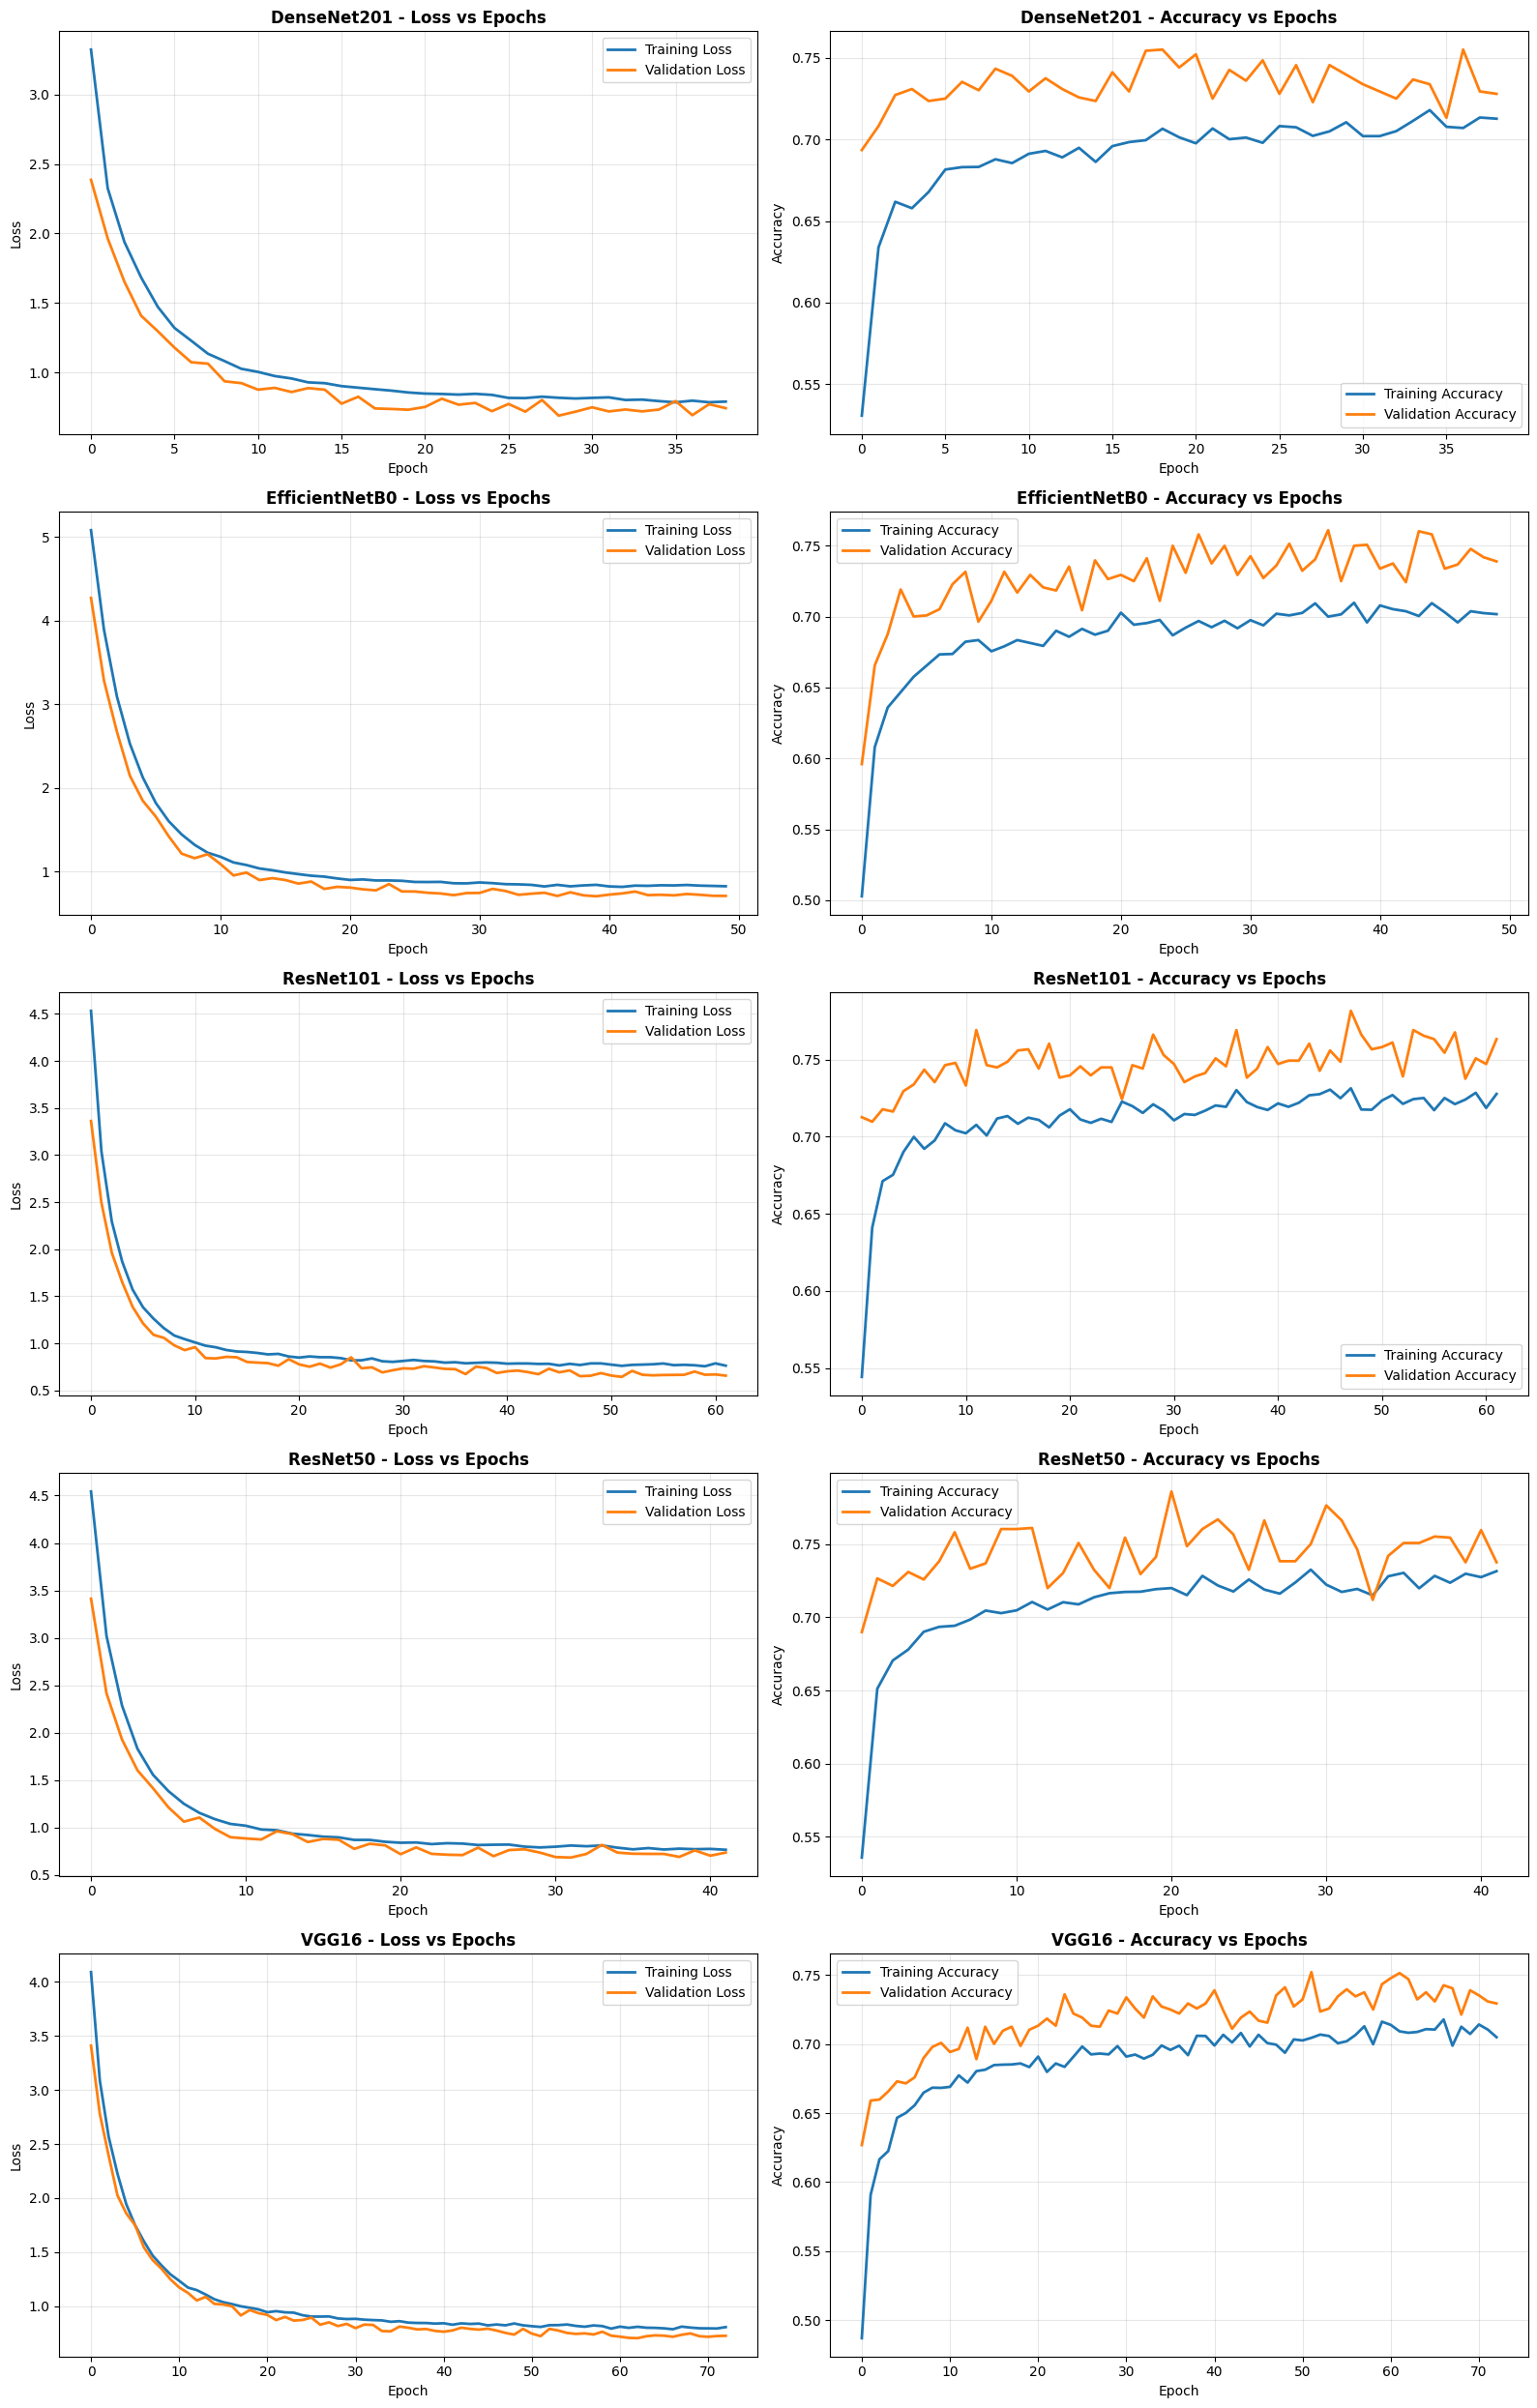

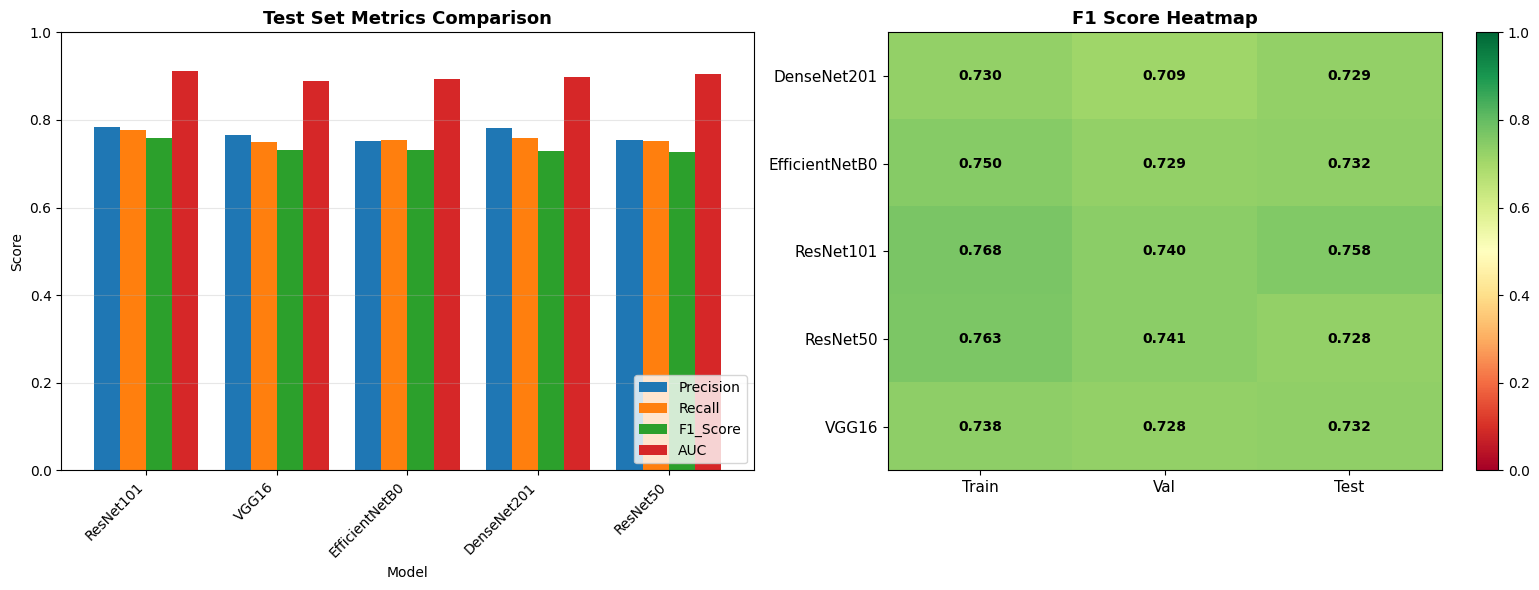

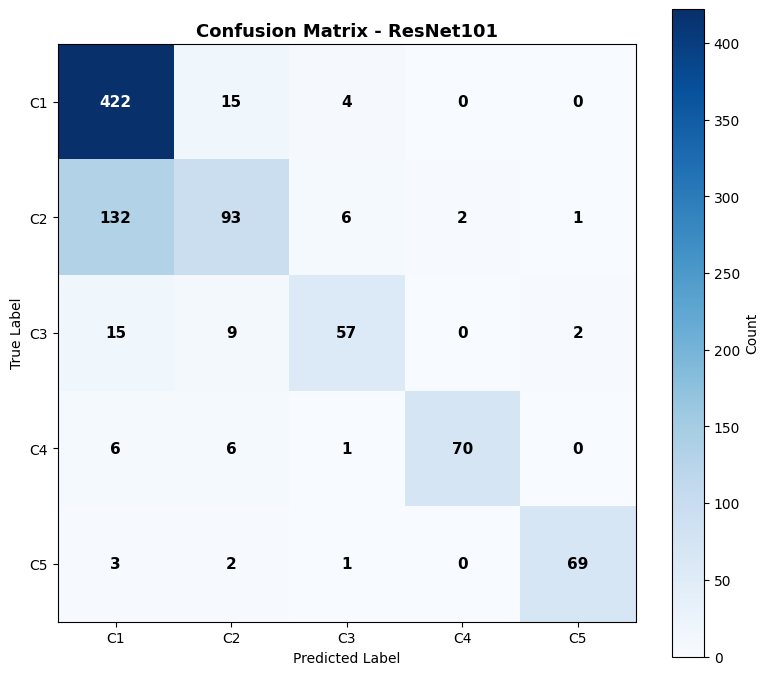


DETAILED CLASSIFICATION REPORT - ResNet101 (Test Set)
              precision    recall  f1-score   support

          C1     0.7301    0.9569    0.8283       441
          C2     0.7440    0.3974    0.5181       234
          C3     0.8261    0.6867    0.7500        83
          C4     0.9722    0.8434    0.9032        83
          C5     0.9583    0.9200    0.9388        75

    accuracy                         0.7762       916
   macro avg     0.8461    0.7609    0.7877       916
weighted avg     0.7830    0.7762    0.7578       916



In [10]:
Path('/kaggle/working/results').mkdir(parents=True, exist_ok=True)

num_models = len(histories)
fig, axes  = plt.subplots(num_models, 2, figsize=(16, 5 * num_models))
if num_models == 1:
    axes = np.expand_dims(axes, 0)

for idx, (model_name, history) in enumerate(sorted(histories.items())):
    ax_loss = axes[idx, 0]
    ax_acc  = axes[idx, 1]

    ax_loss.plot(history.history['loss'],    label='Training Loss',    linewidth=2)
    ax_loss.plot(history.history['val_loss'], label='Validation Loss',  linewidth=2)
    ax_loss.set_title(f'{model_name} - Loss vs Epochs', fontsize=12, fontweight='bold')
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
    ax_loss.legend(fontsize=10); ax_loss.grid(True, alpha=0.3)

    ax_acc.plot(history.history['accuracy'],    label='Training Accuracy',   linewidth=2)
    ax_acc.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax_acc.set_title(f'{model_name} - Accuracy vs Epochs', fontsize=12, fontweight='bold')
    ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(fontsize=10); ax_acc.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

test_metrics = (results_df[results_df['Subset'] == 'Test']
                .set_index('Model')[['Precision', 'Recall', 'F1_Score', 'AUC']])
test_metrics_sorted = test_metrics.sort_values('F1_Score', ascending=False)

ax1 = axes[0]
test_metrics_sorted.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title('Test Set Metrics Comparison', fontsize=13, fontweight='bold')
ax1.set_ylabel('Score'); ax1.set_xlabel('Model'); ax1.set_ylim(0, 1)
ax1.legend(fontsize=10, loc='lower right'); ax1.grid(True, alpha=0.3, axis='y')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax2 = axes[1]
metrics_pivot = (results_df
                 .pivot_table(index='Model', columns='Subset', values='F1_Score')
                 .reindex(['Test', 'Val', 'Train'], axis=1)[['Train', 'Val', 'Test']])

im = ax2.imshow(metrics_pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax2.set_xticks(np.arange(len(metrics_pivot.columns))); ax2.set_yticks(np.arange(len(metrics_pivot.index)))
ax2.set_xticklabels(metrics_pivot.columns, fontsize=11); ax2.set_yticklabels(metrics_pivot.index, fontsize=11)
ax2.set_title('F1 Score Heatmap', fontsize=13, fontweight='bold')

for i in range(len(metrics_pivot.index)):
    for j in range(len(metrics_pivot.columns)):
        ax2.text(j, i, f'{metrics_pivot.values[i,j]:.3f}',
                 ha="center", va="center", color="black", fontsize=10, fontweight='bold')

plt.colorbar(im, ax=ax2); plt.tight_layout()
plt.savefig('/kaggle/working/results/metrics_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

# confusion matrix for the best-performing model
best_model_obj = trained_models[best_model_name]
preprocess_fn  = PREPROCESS_FN[best_model_name]
test_eval_ds   = make_dataset(
    test_df['filepath'].tolist(), test_df['label_idx'].tolist(),
    preprocess_fn, augment=False, shuffle=False
)
test_probs = best_model_obj.predict(test_eval_ds, verbose=0)
test_preds = np.argmax(test_probs, axis=1)

cm          = confusion_matrix(test_true_all, test_preds)
class_names = [f'C{i}' for i in range(1, 6)]

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_title(f'Confusion Matrix - {best_model_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
ax.set_xticks(np.arange(len(class_names))); ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, fontsize=10); ax.set_yticklabels(class_names, fontsize=10)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f'{cm[i,j]}',
                ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black",
                fontsize=11, fontweight='bold')

plt.colorbar(im, ax=ax, label='Count'); plt.tight_layout()
plt.savefig('/kaggle/working/results/confusion_matrix_best_model.png', dpi=150, bbox_inches='tight'); plt.show()

print(f"\n{'='*80}")
print(f"DETAILED CLASSIFICATION REPORT - {best_model_name} (Test Set)")
print(f"{'='*80}")
print(classification_report(test_true_all, test_preds, target_names=class_names, digits=4, zero_division=0))


ResNet100 clearly seems to be performing better in this case